In [5]:
import numpy as np
import matplotlib.pyplot as plt
from core.pricer import forward_price
from core.greeks import delta

## Section 1 — Forward price vs Repo rate

The forward price compresses as the repo rate increases. Nothing surprising here, but the maturity effect is what matters. A 3-month option barely moves while a 2-year forward drops to 58 with a 30% borrow rate. If you price or hedge a long-dated option without accounting for repo, you are simply using the wrong forward.

In [2]:
S = 100
r = 0.05
q = 0.02
rho_range = np.linspace(0, 0.30, 200)
maturities = {"3m": 0.25, "6m": 0.5, "1y": 1.0, "2y": 2.0}

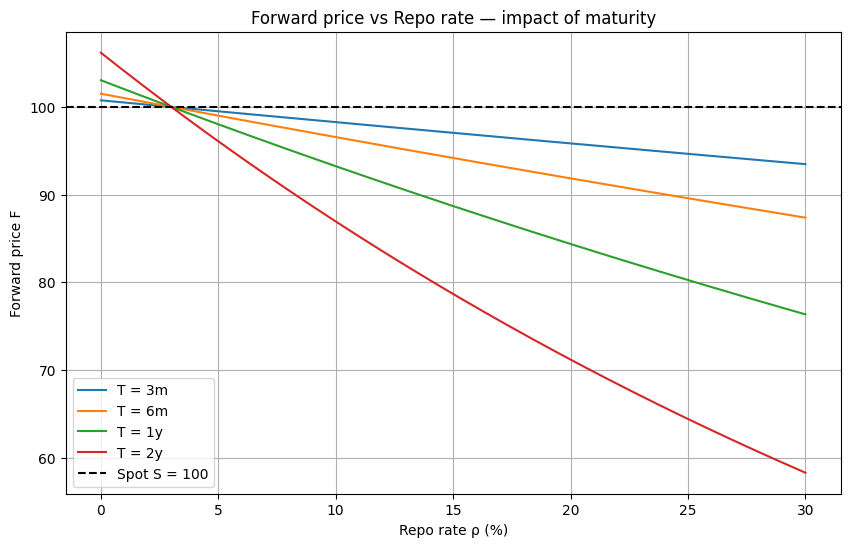

In [3]:
plt.figure(figsize=(10, 6))

for label, T in maturities.items():
    forwards = forward_price(S, r, q, rho_range, T)
    plt.plot(rho_range * 100, forwards, label=f"T = {label}")

plt.axhline(y=S, color='black', linestyle='--', label="Spot S = 100")
plt.xlabel("Repo rate ρ (%)")
plt.ylabel("Forward price F")
plt.title("Forward price vs Repo rate — impact of maturity")
plt.legend()
plt.grid(True)
plt.show()

## Section 2 — Delta vs Repo rate

Delta reflects how sensitive the option price is to a move in the underlying, but what this graph 
shows is that repo destroys that sensitivity for long-dated options.

When the repo rate rises, the forward price drops. The forward is what the model uses as the effective 
reference price when computing delta, not the spot. At 30% borrow over 2 years, the forward has already 
fallen to 58 while the strike sits at 100. The model sees a 72% rally needed just to finish in the money, 
so the delta collapses toward zero.

Short-dated options are barely affected because the forward does not drift far from spot over a short 
horizon. But for a 1 or 2 year option, a high repo rate is essentially equivalent to the stock having 
already sold off massively, even if the spot has not moved at all.

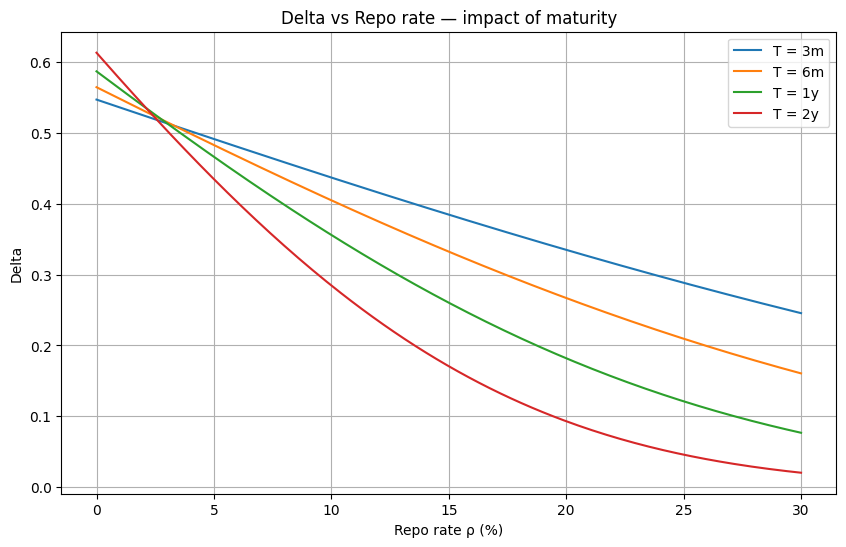

In [8]:
sigma = 0.2
K= 100

plt.figure(figsize=(10, 6))

for label, T in maturities.items():
    deltas = delta(S, K,  r, q, rho_range, T, sigma)
    plt.plot(rho_range * 100, deltas, label=f"T = {label}")
plt.xlabel("Repo rate ρ (%)")
plt.ylabel("Delta")
plt.title("Delta vs Repo rate — impact of maturity")
plt.legend()
plt.grid(True)
plt.show()

## Section 3 — Repo-Adjusted Delta

The gap between the two delta curves is not uniform across spot levels, it peaks around the ATM 
and fades away deep in or out of the money. This makes sense because delta is most sensitive to 
the forward near the strike, which is exactly where repo has the most distorting effect.

The right panel puts a number on it. At ATM the hedge error reaches 0.34, meaning 34 shares of 
over-hedge per 100 shares notional. Deep ITM or OTM the error shrinks because the delta is 
already close to 1 or 0 regardless of repo. The dangerous zone is always around the strike.

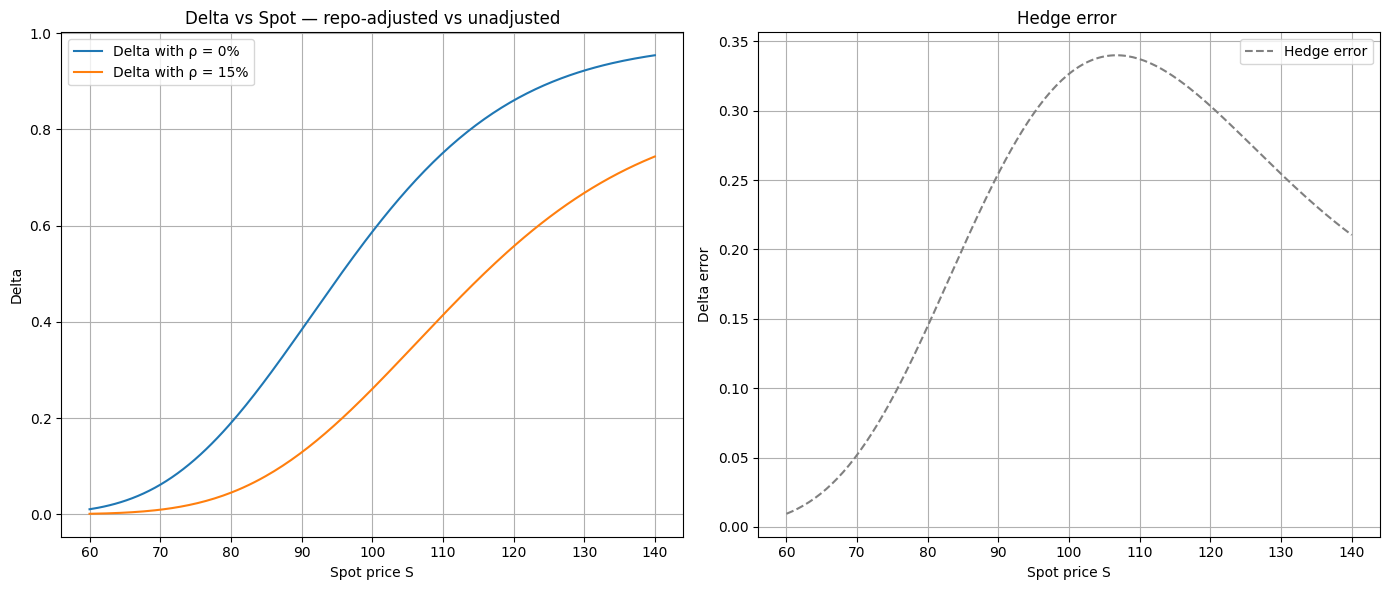

In [22]:
rho_adj = 0.15
S_range = np.linspace(60, 140, 200)

T = 1


delta_rho_zero = delta(S_range, K, r, q, 0.0, T, sigma)
delta_rho_adjusted = delta(S_range, K, r, q, rho_adj, T, sigma)
error =  delta_rho_zero - delta_rho_adjusted

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.plot(S_range, delta_rho_zero, label="Delta with ρ = 0%")
ax1.plot(S_range, delta_rho_adjusted, label=f"Delta with ρ = {rho_adj*100:.0f}%")
ax1.set_title("Delta vs Spot — repo-adjusted vs unadjusted")
ax1.set_xlabel("Spot price S")
ax1.set_ylabel("Delta")
ax1.legend()
ax1.grid(True)

ax2.plot(S_range, error, color='grey', linestyle='--', label="Hedge error")
ax2.set_title("Hedge error ")
ax2.set_xlabel("Spot price S")
ax2.set_ylabel("Delta error")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()